# Topological spline graph on synthetic point distributions

The reusable implementation lives in `topological_graph_embedding.visualization.workflows.synthetic`. The static and interactive views use the same four-panel visualization as the other notebooks: fitted graph, graph embedding, metro-map lines, and metro-map points. This notebook only sets parameters and calls it.

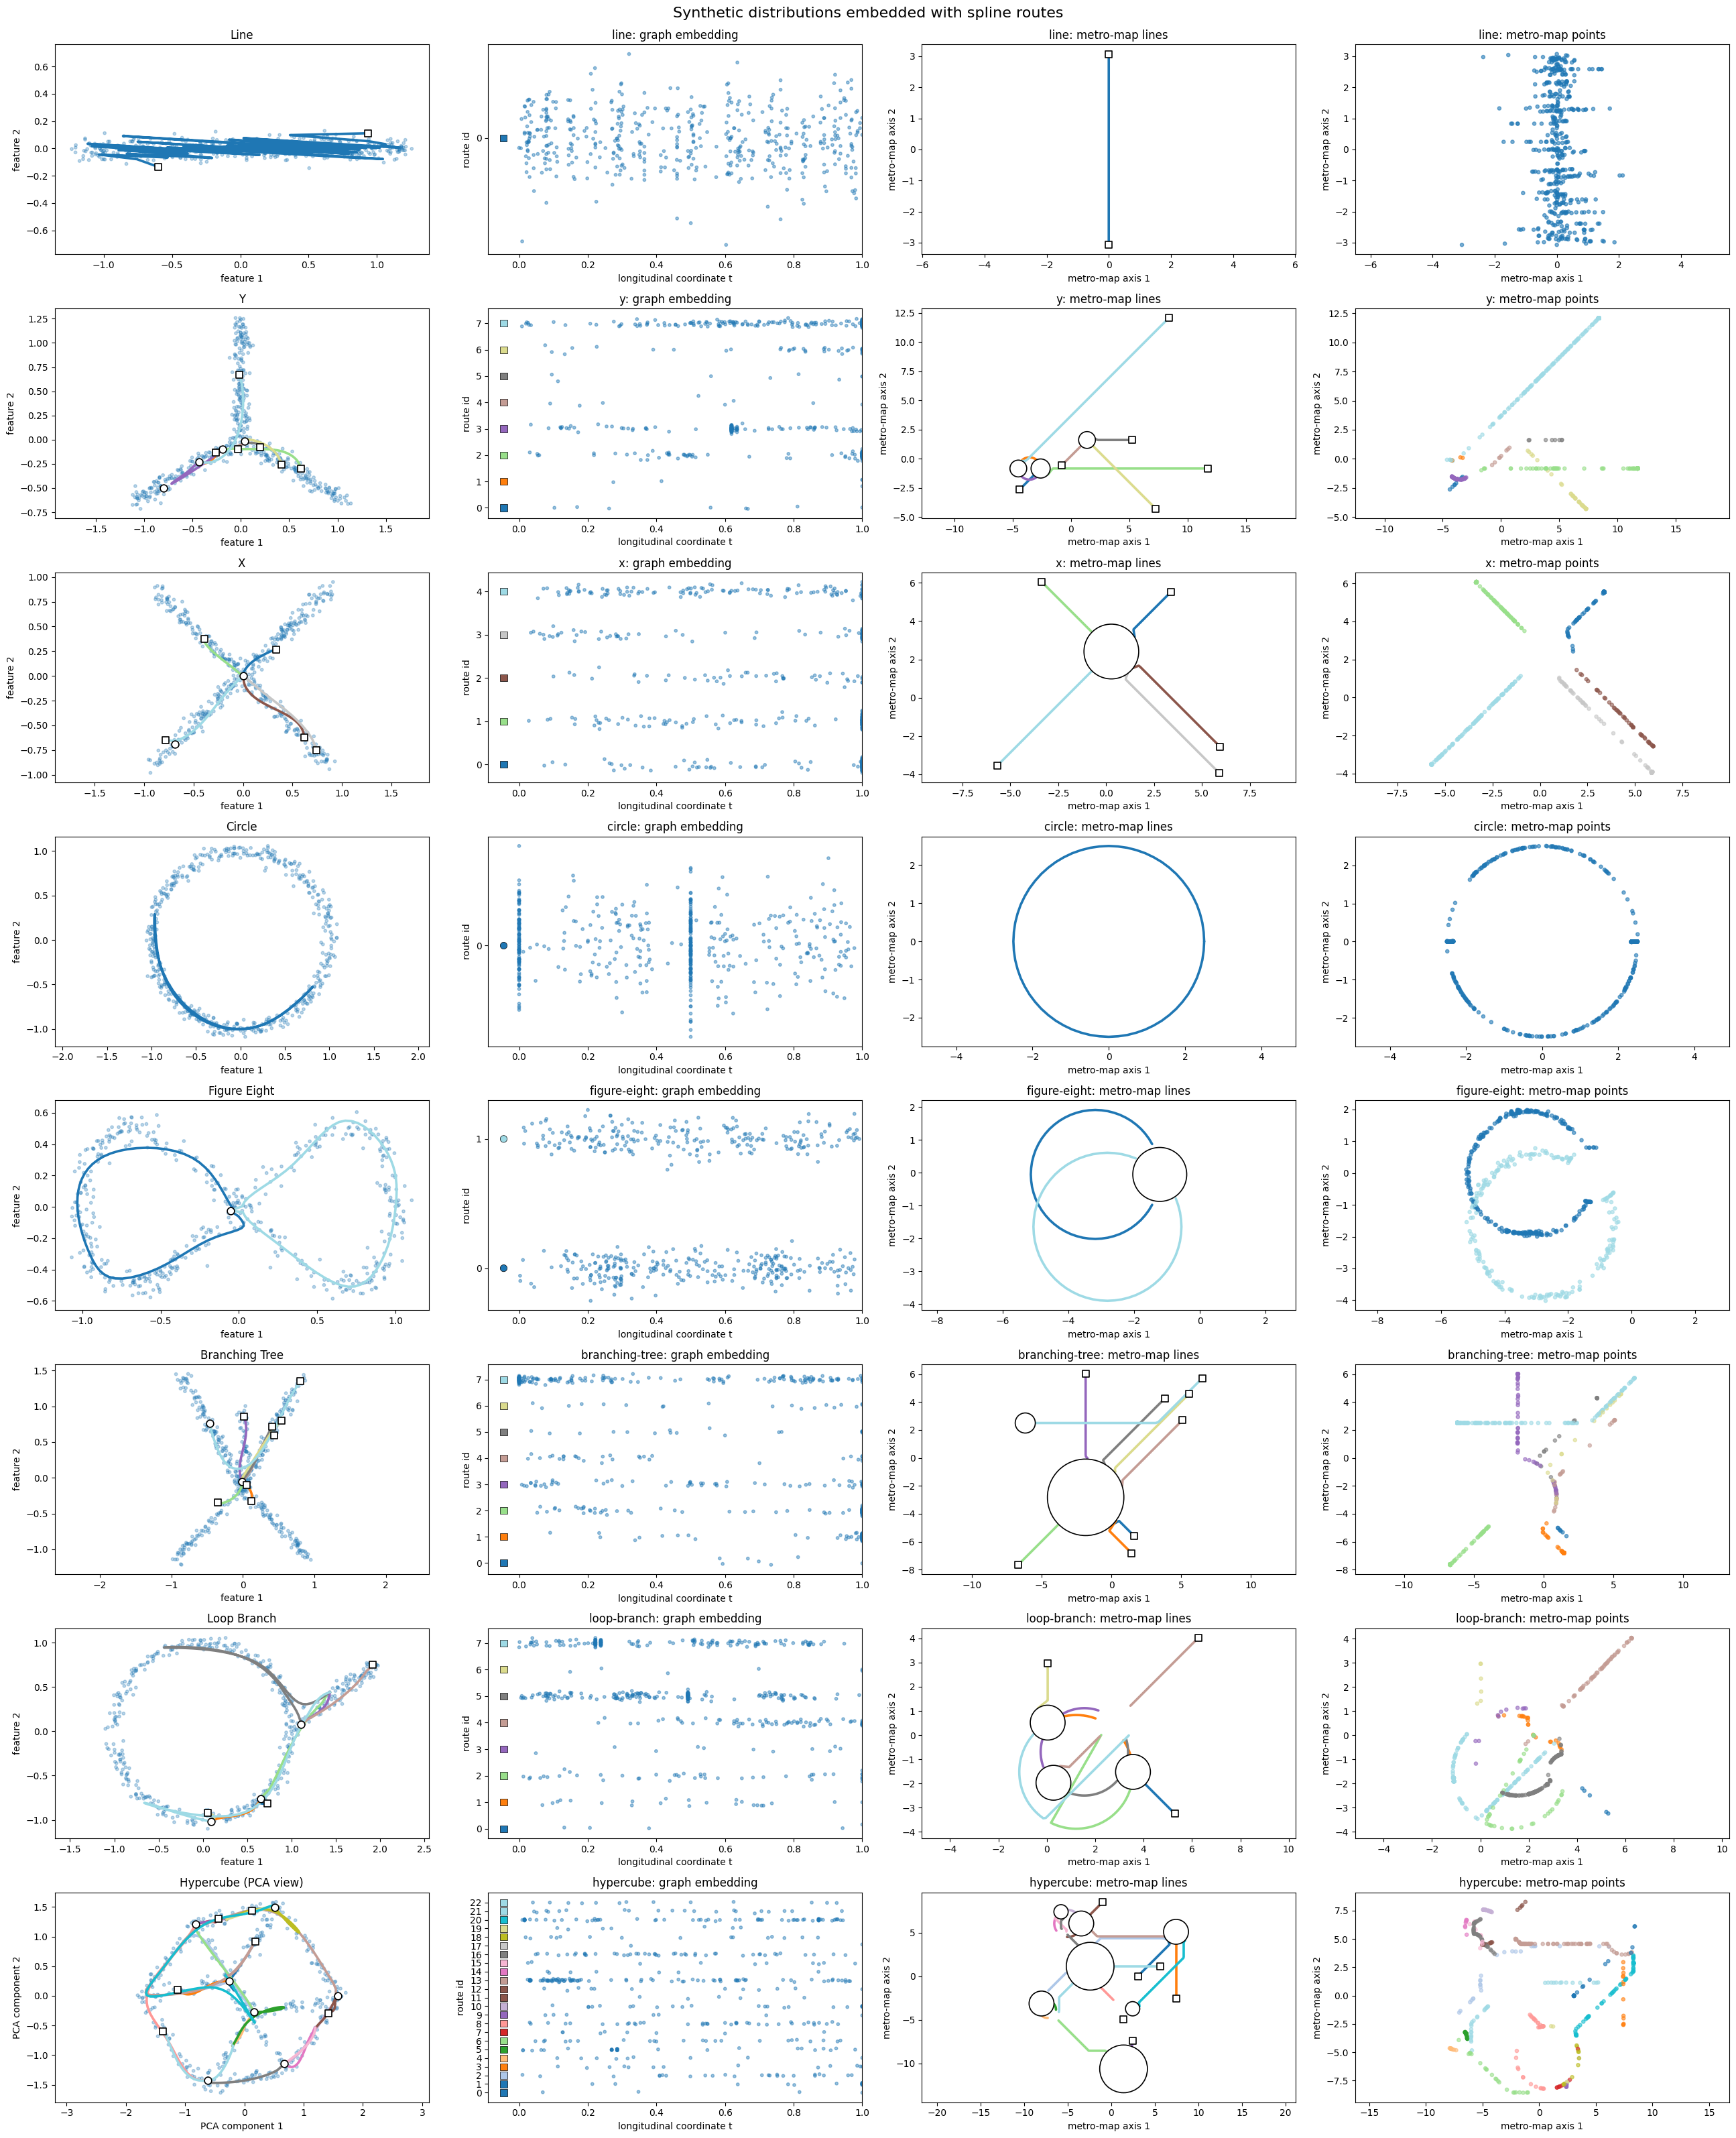

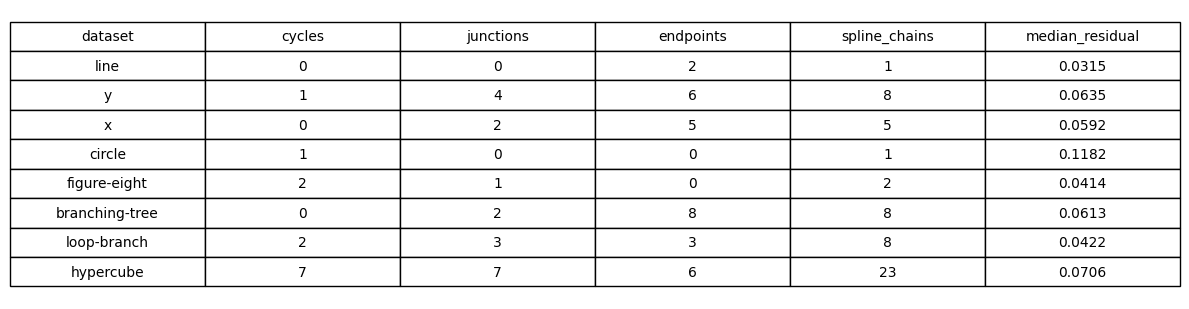

In [1]:
from pathlib import Path
import sys

working_dir = Path.cwd().resolve()
notebooks_dir = working_dir / 'notebooks' if (working_dir / 'notebooks' / '__init__.py').exists() else working_dir
project_root = notebooks_dir.parent
if not (project_root / 'topological_graph_embedding').exists():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory')
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from topological_graph_embedding.visualization.workflows.synthetic import (
    build_datasets,
    fit_datasets,
    _plot_summary,
)
from topological_graph_embedding.visualization.plots import plot_embedding_row

HYPERCUBE_DIM = 3
N_POINTS = 500
NOISE = 0.045
N_CENTROIDS = 50
SPLINE_SMOOTHING = 0.005
MAX_CYCLES = 5

datasets = build_datasets(
    n=N_POINTS,
    noise=NOISE,
    hypercube_dim=HYPERCUBE_DIM,
)
models, projections, summary = fit_datasets(
    datasets,
    n_centroids=N_CENTROIDS,
    spline_smoothing=SPLINE_SMOOTHING,
    max_cycles=MAX_CYCLES,
)

fig, axes = plt.subplots(
    len(datasets), 4, figsize=(26, 4 * len(datasets)), squeeze=False,
)
reducers = {
    name: PCA(n_components=2, random_state=0).fit(points)
    if points.shape[1] > 2 else None
    for name, points in datasets.items()
}
for row, (name, points) in enumerate(datasets.items()):
    labels = np.zeros(len(points), dtype=int)
    title = name.replace('-', ' ').title()
    if reducers[name] is not None:
        title += ' (PCA view)'
    plot_embedding_row(
        axes[row], points, labels, models[name], projections[name],
        projected_title=title,
        graph_title=f'{name}: graph embedding',
        metro_lines_title=f'{name}: metro-map lines',
        metro_points_title=f'{name}: metro-map points',
        reducer=reducers[name],
        jitter_seed=row,
        metro_residual_width=0.02,
    )

fig.suptitle(
    'Synthetic distributions embedded with spline routes',
    fontsize=16, y=0.995,
)
fig.tight_layout()
figure_dir = project_root / 'notebooks' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'synthetic_distributions.png', dpi=160, bbox_inches='tight')
plt.show()
_plot_summary(summary, figure_dir)

## Interactive parameter exploration

Select a dataset, adjust the fitting parameters, and press **Refit selected dataset**.

In [2]:
from topological_graph_embedding.visualization.workflows.synthetic import display_interactive_controls

display_interactive_controls(datasets)